In [1]:
from torch.utils.data import Dataset
import time
import pickle
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import torch.optim as optim
import numpy as np
import argparse
from torch.optim.lr_scheduler import StepLR
from tqdm import tqdm
import copy
import optuna
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from IPython.display import clear_output
torch.manual_seed(42)
np.random.seed(42)
plt.rcParams['font.sans-serif'] = ['SimHei']  # 'SimHei'是黑体的意思
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
import joblib

In [2]:
%matplotlib inline

In [3]:
import sys, torch, os

print("Python路径:", sys.executable)
print("CUDA可用:", torch.cuda.is_available())
print("PyTorch CUDA版本:", torch.version.cuda)
# print("cuBLAS版本:", torch._C._cublas_version())
print("系统PATH:", os.environ["PATH"])
print("CUDA_HOME:", os.environ.get("CUDA_HOME"))

Python路径: D:\Anaconda\envs\NAM\python.exe
CUDA可用: True
PyTorch CUDA版本: 11.3
系统PATH: D:\Anaconda;D:\Anaconda\Library\mingw-w64\bin;D:\Anaconda\Library\usr\bin;D:\Anaconda\Library\bin;D:\Anaconda\Scripts;D:\Anaconda\bin;D:\Anaconda\condabin;D:\Anaconda;D:\Anaconda\Library\mingw-w64\bin;D:\Anaconda\Library\usr\bin;D:\Anaconda\Library\bin;D:\Anaconda\Scripts;f:\Program Files\cursor\resources\app\bin;E:\oneapi-2022\mpi\latest\bin;E:\oneapi-2022\mpi\latest\bin\release;E:\oneapi-2022\mpi\latest\libfabric\bin;E:\oneapi-2022\mpi\latest\libfabric\bin\utils;E:\oneapi-2022\tbb\latest\redist\intel64\vc_mt;E:\oneapi-2022\tbb\latest\redist\ia32\vc_mt;E:\oneapi-2022\compiler\latest\windows\redist\intel64_win\compiler;E:\oneapi-2022\compiler\latest\windows\redist\ia32_win\compiler;E:\SIMULIA\Commands;C:\Program Files\Microsoft MPI\Bin;C:\Program Files\Common Files\Oracle\Java\javapath;C:\Windows\system32;C:\Windows;C:\Windows\System32\Wbem;C:\Windows\System32\WindowsPowerShell\v1.0;C:\Windows\System32\

In [4]:
arr1 = np.array([[1, 2], [3, 4]])  # 形状 (2, 2)
arr2 = np.array([[5, 6], [7, 8]])  # 形状 (2, 2)
# 方法3：沿 axis=1 拼接
combined = np.concatenate([arr1, arr2], axis=1)

print(combined.shape)

(2, 4)


In [5]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
class DataProcessor:
    def __init__(self, raw_data):
        """
        Args:
            raw_data: 原始数据集（需是三维数组格式）
            seq_length: 序列长度（根据 `create_inout_sequences` 中的逻辑）
        """
        self.raw_data = raw_data
        self.train = None
        self.valid = None
        self.test = None

    def split_dataset(self, train_scale=0.8, valid_scale=0.15):
        """划分数据集"""
        data = self.raw_data.to_numpy()
        total = len(data)
        train_num = int(train_scale * total)
        valid_num = int(valid_scale * total)
        
        self.train = data[:train_num,:]
        self.valid = data[train_num:train_num+valid_num,:]
        self.test = data[train_num+valid_num:,:]
        return self.train, self.valid, self.test
    
    def create_inout_sequences(self,input_data, tw):
        self.input_seq = []
        L = int(len(input_data)/tw)
        j=0
        #print(L)
        for i in range(L):
            train_seq = input_data[j:j+tw]
            #train_label = input_data[i+tw:i+tw+1]
            #inout_seq.append((train_seq ,train_label))
            j=j+2742
            self.input_seq.append(train_seq )
        return self.input_seq

In [7]:
class mydata(Dataset):
    def __init__(self,Data_input,Data_output):
        self.Data_input = torch.tensor(Data_input, dtype=torch.float32)
        self.Data_output = torch.tensor(Data_output, dtype=torch.float32)
    def __len__(self):
        return len(self.Data_input)
    def __getitem__(self, index):
        return self.Data_input[index],self.Data_output[index]

In [8]:
all_data = pd.read_excel("combined_data.xlsx", sheet_name='Sheet1')

In [9]:
# train_dataset,valid_dataset,test_dataset=dataset_sp(all_data)
processor = DataProcessor(all_data)
train_dataset,valid_dataset,test_dataset=processor.split_dataset()

In [10]:
train_inputs=train_dataset[:,0]
train_inputs=train_inputs.reshape(-1,1)
#训练输入数据集 (0.8*  区间是左闭右开  ndarray
train_outputs=train_dataset[:,1] #训练输出数据集  (0.8
train_outputs=train_outputs.reshape(-1,1)

valid_inputs=valid_dataset[:,0]
valid_inputs=valid_inputs.reshape(-1,1)

valid_outputs=valid_dataset[:,1]
valid_outputs=valid_outputs.reshape(-1,1)

test_inputs=test_dataset[:,0]
test_inputs=test_inputs.reshape(-1,1)

test_outputs=test_dataset[:,1]
test_outputs=test_outputs.reshape(-1,1)

In [11]:
train_inputs.shape

(65808, 1)

In [12]:
scaler_input = MinMaxScaler(feature_range=(0, 1))
scaler_output = MinMaxScaler(feature_range=(0, 1))

train_input = scaler_input.fit_transform(train_inputs)
train_output = scaler_output.fit_transform(train_outputs)
valid_input = scaler_input.transform(valid_inputs)
valid_output = scaler_output.transform(valid_outputs)
test_input = scaler_input.transform(test_inputs)
test_output = scaler_output.transform(test_outputs)
#train_num=len(train_input)
#val_num = len(valid_input)
# # 保存输入归一化器
# with open('scaler_input.pkl', 'wb') as f:
#     pickle.dump(scaler_input, f)
# # 保存输出归一化器
# with open('scaler_output.pkl', 'wb') as f:
#     pickle.dump(scaler_output, f)
joblib.dump(scaler_input, 'scaler_input.pkl')
joblib.dump(scaler_output, 'scaler_output.pkl')

['scaler_output.pkl']

In [13]:
print(train_input)

[[0.22495274]
 [0.22663619]
 [0.22831962]
 ...
 [0.22812048]
 [0.22688672]
 [0.22565295]]


In [14]:
print(train_output)

[[0.18307238]
 [0.18628928]
 [0.1895063 ]
 ...
 [0.18882112]
 [0.18685582]
 [0.18489053]]


In [15]:
train_output.shape
a1=scaler_output.inverse_transform(train_output)
print(a1)

[[-0.23911453]
 [-0.07380675]
 [ 0.09150737]
 ...
 [ 0.05629784]
 [-0.04469397]
 [-0.14568497]]


In [16]:
# def create_inout_sequences(input_data, tw):
#     inout_seq = []
#     L = int(len(input_data)/tw)
#     j=0
#     #print(L)
#     for i in range(L):
#         train_seq = input_data[j:j+tw]
#         #train_label = input_data[i+tw:i+tw+1]
#         #inout_seq.append((train_seq ,train_label))
#         j=j+1141
#         inout_seq.append(train_seq )
#     return inout_seq

In [17]:
tw = 2742
# train_input1 = create_inout_sequences(np.array(train_input), tw)
# valid_input1 = create_inout_sequences(np.array(valid_input), tw)
# test_input1 = create_inout_sequences(np.array(test_input), tw)
# train_output1 = create_inout_sequences(np.array(train_output), tw)
# valid_output1 = create_inout_sequences(np.array(valid_output), tw)
# test_output1 = create_inout_sequences(np.array(test_output), tw)
train_input1 = processor.create_inout_sequences(np.array(train_input), tw)
valid_input1 =  processor.create_inout_sequences(np.array(valid_input), tw)
test_input1 =  processor.create_inout_sequences(np.array(test_input), tw)
train_output1 =  processor.create_inout_sequences(np.array(train_output), tw)
valid_output1 = processor. create_inout_sequences(np.array(valid_output), tw)
test_output1 =  processor.create_inout_sequences(np.array(test_output), tw)

In [18]:
train_num=len(train_input1)
val_num = len(valid_input1)
test_num = len(test_input1)

In [19]:
test_num 

1

In [20]:
np.array(train_input1).shape

(24, 2742, 1)

In [21]:
np.array(train_output1).shape

(24, 2742, 1)

In [22]:
np.array(test_output1).shape

(1, 2742, 1)

In [23]:
tr_dataset=mydata(train_input1,train_output1)
va_dataset=mydata(valid_input1,valid_output1)
te_dataset=mydata(test_input1,test_output1)

C:\Users\97548\AppData\Local\Temp\ipykernel_24784\1822385444.py:3: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at  C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:204.)
  self.Data_input = torch.tensor(Data_input, dtype=torch.float32)


In [24]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, batch_size, bidirectional=True):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.output_size = output_size
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1 # 双向为2，单向为1
        self.batch_size = batch_size
        
        # 增加 bidirectional 参数
        self.lstm = nn.LSTM(self.input_size, self.hidden_size, self.num_layers, batch_first=True, bidirectional=self.bidirectional)
        
        # 线性层的输入维度调整：如果是双向，输入维度要乘 2
        self.linear = nn.Linear(self.hidden_size * self.num_directions, self.output_size)

    def forward(self, input_seq):
        # input_seq 形状: (batch_size, seq_len, input_size)
        batch_size = input_seq.shape[0]
        
        # =================== 新增：预热填充 (Warm-up Padding) ===================
        # 目的：消除开头和结尾的“冷启动”误差
        warmup_steps = 30  # 预热步数，30步足够让 LSTM 状态稳定
        
        # 1. 取出序列的第一个时间步，重复 30 次，拼接到最前面
        # 形状变化: (batch, 1, input) -> (batch, 30, input)
        start_padding = input_seq[:, 0:1, :].repeat(1, warmup_steps, 1)
        
        # 2. 如果是双向，取出最后一个时间步，重复 30 次，拼接到最后面
        if self.bidirectional:
            end_padding = input_seq[:, -1:, :].repeat(1, warmup_steps, 1)
            # 拼接：[开头填充, 原始数据, 结尾填充]
            x_padded = torch.cat([start_padding, input_seq, end_padding], dim=1)
        else:
            # 单向拼接：[开头填充, 原始数据]
            x_padded = torch.cat([start_padding, input_seq], dim=1)
        # ======================================================================

        # 初始化隐状态 (0)
        h_0 = torch.zeros(self.num_directions * self.num_layers, batch_size, self.hidden_size).to(device)
        c_0 = torch.zeros(self.num_directions * self.num_layers, batch_size, self.hidden_size).to(device)
        
        # 将填充后的数据送入 LSTM
        # output_padded 形状: (batch, seq_len + padding, hidden * directions)
        output_padded, _ = self.lstm(x_padded, (h_0, c_0))
        
        # =================== 新增：切除填充 (Trim Padding) ====================
        # 把刚才加上的“预热”部分的输出切掉，只保留原始长度的输出
        if self.bidirectional:
            # 双向：切掉头部的 warmup_steps 和 尾部的 warmup_steps
            output = output_padded[:, warmup_steps:-warmup_steps, :]
        else:
            # 单向：只切掉头部的 warmup_steps
            output = output_padded[:, warmup_steps:, :]
        # ======================================================================
        
        pred = self.linear(output)
        
        return pred

In [25]:
args = argparse.Namespace(
    input_size=1,
    hidden_size=30,
    num_layers=3,
    output_size=1,
    bidirectional=True,
    batch_size=16,
    optimizer='adam',
    lr=0.001,
    weight_decay=1e-5,
    step_size=100,
    gamma=0.9,
    epochs=2500
)

In [26]:
train_loader = torch.utils.data.DataLoader(tr_dataset,
                                               batch_size=args.batch_size, shuffle=True,
                                               num_workers=0,pin_memory=True)
validate_loader = torch.utils.data.DataLoader(va_dataset,
                                                  batch_size=1, shuffle=False,
                                                  num_workers=0,pin_memory=True)
test_loader = torch.utils.data.DataLoader(te_dataset,
                                                  batch_size=1, shuffle=False,
                                                  num_workers=0,pin_memory=True)

Epoch [244/2500], 训练集loss: 0.000469, 测试集loss:0.000699


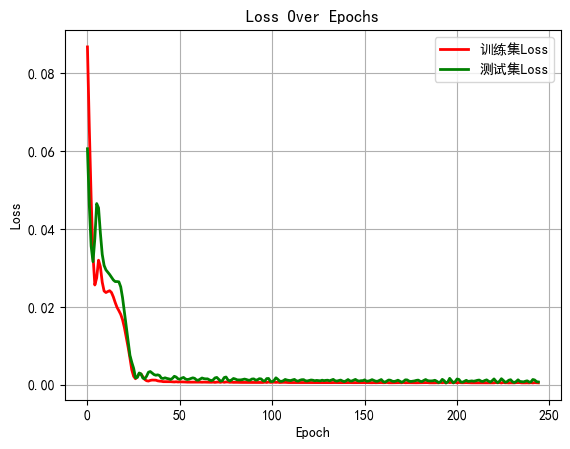

最优模型已保存为 best_model_r.pth


In [27]:
input_size, hidden_size, num_layers = args.input_size, args.hidden_size, args.num_layers
output_size = args.output_size

# if args.bidirectional:
#     model = BiLSTM(input_size, hidden_size, num_layers, output_size, batch_size=args.batch_size).to(device)
# else:
#     model = LSTM(input_size, hidden_size, num_layers, output_size, batch_size=args.batch_size).to(device)
# 【关键修改】统一使用修正后的 LSTM 类，并传入 bidirectional 参数
if args.bidirectional:
    model = LSTM(input_size, hidden_size, num_layers, output_size, batch_size=args.batch_size, bidirectional=True).to(device)
else:
    model = LSTM(input_size, hidden_size, num_layers, output_size, batch_size=args.batch_size, bidirectional=False).to(device)

loss_function = nn.SmoothL1Loss(reduction='mean').to(device)

if args.optimizer == 'adam':
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
else:
    optimizer = torch.optim.SGD(model.parameters(), lr=args.lr, momentum=0.9)

scheduler = StepLR(optimizer, step_size=args.step_size, gamma=args.gamma)

# training setup
min_epochs = 30
start_epoch = 0
running_epoch_loss = []
val_avg_loss = []
best_model = model    # 初始化
min_val_loss = float('inf')  # 【关键修改】初始化为无穷大，确保能记录下最初的下降
total_step = 0
alpha = 0

# ==================== 新增：早停参数 ====================
patience = 50       # 耐心值：当验证集 loss 连续 20 个 epoch 没有下降时停止
counter = 0         # 计数器
early_stop = False  # 停止标志位
# =======================================================

for epoch in range(start_epoch, args.epochs):
    # 如果触发了早停，跳出循环
    if early_stop:
        print("早停触发，结束训练循环。")
        break

    model.train()
    running_loss = 0.0
    
    for step, data in enumerate(train_loader):
        total_step = total_step + 1
        seq, label = data
        seq = seq.to(device)
        label = label.to(device)
        
        optimizer.zero_grad()
        y_pred = model(seq)
        
        # 你的反归一化和物理loss代码（已保留注释状态）
        # ... (省略注释内容以保持整洁) ...
        
        loss_data = loss_function(y_pred, label)
        loss_dis = loss_data
        loss_dis.backward()
        optimizer.step()
        running_loss += loss_dis.item() * seq.shape[0]
        
    running_epoch_loss1 = running_loss / train_num
    running_epoch_loss.append(running_epoch_loss1)
    scheduler.step()
    
    # validation
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for step, val_data in enumerate(validate_loader):
            val_input, val_output = val_data
            # val_output = val_output # 原代码这行有点多余
            val_output_predict = model(val_input.to(device))
            val_loss_dis = loss_function(val_output_predict, val_output.to(device))
            total_loss = total_loss + val_loss_dis.item() * val_input.shape[0]
            
    val_avg_loss1 = total_loss / val_num
    val_avg_loss.append(val_avg_loss1)

    # ==================== 修改：早停逻辑核心 ====================
    if epoch > min_epochs:
        if val_avg_loss1 < min_val_loss:
            min_val_loss = val_avg_loss1
            best_model = copy.deepcopy(model)
            counter = 0  # 如果 loss 创新低，重置计数器
            print(f"Epoch {epoch}: 验证集 Loss 创新低 ({min_val_loss:.6f})，模型已保存。")
        else:
            counter += 1
            print(f"Epoch {epoch}: 验证集 Loss 未下降 (计数: {counter}/{patience})")
            if counter >= patience:
                print(f"验证集 Loss 连续 {patience} 个 Epoch 未下降，触发早停！")
                early_stop = True # 标记结束，将在下一次循环头部 break，或者直接在这里 break
                # 这里直接 break 也可以，但如果在 break 前需要绘图，请保留绘图代码
    # ===========================================================

    # 绘图部分保持不变
    if (epoch + 1) % 10 == 0 or early_stop: # 增加 early_stop 时也绘图
        clear_output(wait=True)  # 清理旧的输出
        print('=====================================================')
        print(f"Epoch [{epoch}/{args.epochs}], 训练集loss: {running_epoch_loss[-1]:.6f}, 测试集loss:{val_avg_loss[-1]:.6f}")
        
        plt.plot(range(len(running_epoch_loss)), running_epoch_loss, 'r-', lw=2, label='训练集Loss')
        plt.plot(range(len(val_avg_loss)), val_avg_loss, 'g-', lw=2, label='测试集Loss')
        # 防止重复添加 legend
        if epoch == 9: 
            plt.legend()
        else:
            plt.legend(loc='upper right')
            
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss Over Epochs')
        plt.grid(True)
        plt.pause(0.1)  # 暂停一小段时间以更新图表

    if early_stop:
        break

# 保存模型
if best_model is not None:
    state = {'models': best_model.state_dict()}
    torch.save(state, 'best_model_r.pth')
    print("最优模型已保存为 best_model_r.pth")
else:
    print("未找到满足条件的 best_model (可能是 min_val_loss 初始值设置过低或训练轮数过少)")

In [28]:
loss_data = {
     'Epoch': list(range(1, len(running_epoch_loss) + 1)),
     'Training Loss': running_epoch_loss,
     'Validation Loss': val_avg_loss
 }

 # 使用 pandas 创建 DataFrame
df = pd.DataFrame(loss_data)

 # 保存为 Excel 文件
df.to_excel('loss_data_r.xlsx', index=False)

print("损失函数数据已保存到 loss_data_r.xlsx 文件")

损失函数数据已保存到 loss_data_r.xlsx 文件


验证集与训练集上的R²系数为: [0.996200442314148, 0.9666985869407654]
验证集与训练集上的RMSE为: [0.016645083, 0.043913662]
验证集与训练集上的MAE为: [0.010843776, 0.03986683]


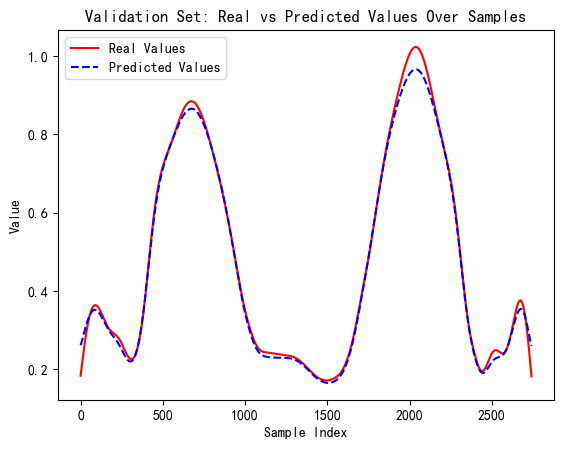

In [29]:
state = torch.load('best_model_r.pth')
model = LSTM(input_size, hidden_size, num_layers, output_size, batch_size=args.batch_size,bidirectional=args.bidirectional).to(device)

# 将加载的参数赋值到模型中
model.load_state_dict(state['models'])
model.eval()
val_preds = []
val_targets = []
train_preds = []
train_targets = []

with torch.no_grad():
    for val_data in validate_loader:
        val_input, val_output = val_data
        #val_output = val_output
        val_output_predict = model(val_input.to(device)).cpu().numpy()  # 预测并转为numpy数组
        
        #val_preds.append(val_output_predict)
        #val_targets.append(val_output.numpy())
        val_targets = val_output.numpy()
        val_preds = val_output_predict
        
#print(np.array(val_targets).shape)
#print(np.array(val_preds).shape)
val_preds = val_preds.reshape(val_preds.shape[0]*val_preds.shape[1],-1)
#print(np.array(val_preds).shape)
val_targets = val_targets.reshape(val_targets.shape[0]*val_targets.shape[1],-1)        
      

#val_preds = np.concatenate(val_preds, axis=0).reshape(-1)
#val_targets = np.concatenate(val_targets, axis=0).reshape(-1)
# np.save('val_preds.npy',val_preds)
# np.save('val_targets.npy',val_targets)
with torch.no_grad():
    for train_data in train_loader:
        train_input, train_output = train_data
        #train_output = train_output
        train_output_predict = model(train_input.to(device)).cpu().numpy()  # 预测并转为numpy数组
        train_targets = train_output.numpy()
        train_preds = train_output_predict

train_preds = train_preds.reshape(train_preds.shape[0]*train_preds.shape[1],-1)
#print(np.array(train_preds).shape)
train_targets = train_targets.reshape(train_targets.shape[0]*train_targets.shape[1],-1)  
#print(np.array(train_targets).shape)
        #train_preds.append(train_output_predict)
        #train_targets.append(train_output.numpy())

#train_preds = np.concatenate(train_preds, axis=0).reshape(-1)

#train_targets = np.concatenate(train_targets, axis=0).reshape(-1)
# np.save('train_preds.npy',train_preds)
# np.save('train_targets.npy',train_targets)
# 计算评价指标
r2=[]
rmse=[]
mae=[]

# val_preds = scaler_output.inverse_transform(val_preds)
# val_targets = scaler_output.inverse_transform(val_targets)
for i in range(1):
    rmse_1 = np.sqrt(mean_squared_error(val_targets[:,i], val_preds[:,i]))
    mae_1 = mean_absolute_error(val_targets[:,i], val_preds[:,i])
    r2_1 = r2_score(val_targets[:,i], val_preds[:,i])
    rmse_2 = np.sqrt(mean_squared_error(train_targets[:,i], train_preds[:,i]))
    mae_2 = mean_absolute_error(train_targets[:,i], train_preds[:,i])
    r2_2 = r2_score(train_targets[:,i], train_preds[:,i])
    r2.append(r2_1)
    r2.append(r2_2)
    rmse.append(rmse_1)
    rmse.append(rmse_2)
    mae.append(mae_1)
    mae.append(mae_2)

print(f"验证集与训练集上的R²系数为: {r2}")
print(f"验证集与训练集上的RMSE为: {rmse}")
print(f"验证集与训练集上的MAE为: {mae}")
x = np.arange(len(val_targets))  # 或者使用其他有意义的x轴值

# 绘制真实值的曲线
plt.figure(1)
plt.plot(x, val_targets[:,0], color='red', label='Real Values', linestyle='-')

# 绘制预测值的曲线
plt.plot(x, val_preds[:,0], color='blue', label='Predicted Values', linestyle='--')

# 设置标题、轴标签和图例
plt.title('Validation Set: Real vs Predicted Values Over Samples')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()


#plt.figure(2)
#plt.plot(x, val_targets[:,1], color='red', label='Real Values', linestyle='-')

# 绘制预测值的曲线
#plt.plot(x, val_preds[:,1], color='blue', label='Predicted Values', linestyle='--')

# 设置标题、轴标签和图例
#plt.title('Validation Set: Real vs Predicted Values Over Samples')
#plt.xlabel('Sample Index')
#plt.ylabel('Value')
#plt.legend()

# # 显示图像
plt.show()

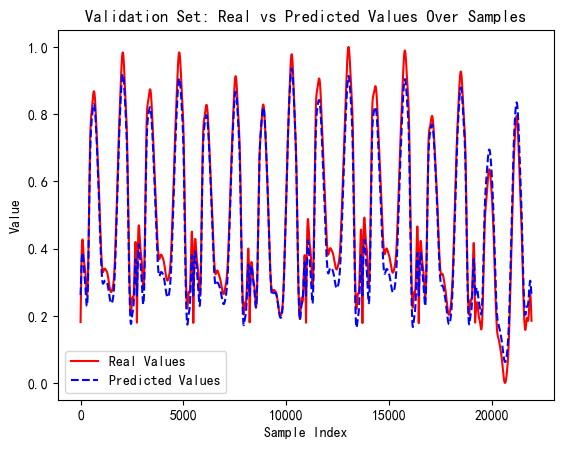

In [30]:
x = np.arange(len(train_targets))  # 或者使用其他有意义的x轴值

# 绘制真实值的曲线
plt.figure(1)
plt.plot(x, train_targets[:,0], color='red', label='Real Values', linestyle='-')

# 绘制预测值的曲线
plt.plot(x, train_preds[:,0], color='blue', label='Predicted Values', linestyle='--')

# 设置标题、轴标签和图例
plt.title('Validation Set: Real vs Predicted Values Over Samples')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()

# plt.figure(2)
# plt.plot(x, train_targets[:,1], color='red', label='Real Values', linestyle='-')

# 绘制预测值的曲线
# plt.plot(x, train_preds[:,1], color='blue', label='Predicted Values', linestyle='--')

# 设置标题、轴标签和图例
# plt.title('Validation Set: Real vs Predicted Values Over Samples')
# plt.xlabel('Sample Index')
# plt.ylabel('Value')
# plt.legend()

# # 显示图像
plt.show()

开始测试集推理...
测试集总推理耗时: 10.08 ms
------------------------------
测试集 R² (决定系数): 0.993039
测试集 RMSE (均方根误差): 1.112346 mm
测试集 MAE (平均绝对误差): 0.907401 mm
测试集 MaxError (最大单点误差): 4.163914 mm
------------------------------


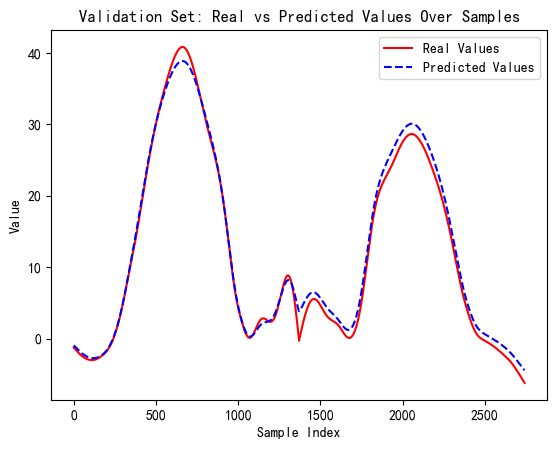

In [31]:
model.eval()
test_preds = []
test_targets = []


# 1. GPU 预热 (可选，但推荐)
# 运行一次空数据让 GPU 进入计算状态，避免第一次冷启动影响计时准确性
if torch.cuda.is_available():
    dummy_input = torch.randn(1, 1032, 1).to(device) # 假设输入维度为 (1, 1032, 1)
    with torch.no_grad():
        _ = model(dummy_input)
    torch.cuda.synchronize() # 等待预热完成

print("开始测试集推理...")

# 2. 记录开始时间
if torch.cuda.is_available():
    torch.cuda.synchronize() # 确保之前的 GPU 任务已完成
start_time = time.time()






with torch.no_grad():
    for test_data in test_loader:
        test_input, test_output = test_data
        #test_output = test_output.reshape(-1)
        test_output_predict = model(test_input.to(device)).cpu().numpy()  # 预测并转为numpy数组
        test_preds=test_output_predict
        test_targets=test_output.numpy()
        
# 3. 记录结束时间
if torch.cuda.is_available():
    torch.cuda.synchronize() # 确保推理任务全部完成
end_time = time.time()

# 4. 计算并打印耗时
total_inference_time = (end_time - start_time) * 1000 # 转换为毫秒
print(f"测试集总推理耗时: {total_inference_time:.2f} ms")



        
#test_preds = np.concatenate(test_preds, axis=0).reshape(-1,)
#test_targets = np.concatenate(test_targets, axis=0).reshape(-1)
test_preds = test_preds.reshape(test_preds.shape[0]*test_preds.shape[1],-1)
test_targets = test_targets.reshape(test_targets.shape[0]*test_targets.shape[1],-1)
# np.save('test_preds.npy',test_preds)
# np.save('test_targets.npy',test_targets)
# rmse_test_new=[]
# mae_test_new=[]
# r2_test_new=[]
# for i in range(1):
#     rmse_test = np.sqrt(mean_squared_error(test_targets[:,i], test_preds[:,i]))
#     mae_test = mean_absolute_error(test_targets[:,i], test_preds[:,i])
#     r2_test = r2_score(test_targets[:,i], test_preds[:,i])
#     rmse_test_new.append( rmse_test)
#     mae_test_new.append( mae_test)
#     r2_test_new.append( r2_test)
# print(f"测试集上的R²系数为: {r2_test_new}")
# print(f"测试集上的RMSE为: {rmse_test_new}")
# print(f"测试集上的MAE为: {mae_test_new}")


# 反归一化 (还原为真实物理量纲)
test_preds_inv = scaler_output.inverse_transform(test_preds)
test_targets_inv = scaler_output.inverse_transform(test_targets)

# 计算各项指标
rmse_test = np.sqrt(mean_squared_error(test_targets_inv, test_preds_inv))
mae_test = mean_absolute_error(test_targets_inv, test_preds_inv)
r2_test = r2_score(test_targets_inv, test_preds_inv)
max_error_test = np.max(np.abs(test_targets_inv - test_preds_inv)) # 最大单点误差

print("-" * 30)
print(f"测试集 R² (决定系数): {r2_test:.6f}")
print(f"测试集 RMSE (均方根误差): {rmse_test:.6f} mm")
print(f"测试集 MAE (平均绝对误差): {mae_test:.6f} mm")
print(f"测试集 MaxError (最大单点误差): {max_error_test:.6f} mm")
print("-" * 30)




x = np.arange(len(test_targets))  # 或者使用其他有意义的x轴值

# 绘制真实值的曲线
plt.figure(1)
plt.plot(x, test_targets_inv[:,0], color='red', label='Real Values', linestyle='-')

# 绘制预测值的曲线
plt.plot(x, test_preds_inv[:,0], color='blue', label='Predicted Values', linestyle='--')

# 设置标题、轴标签和图例
plt.title('Validation Set: Real vs Predicted Values Over Samples')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()


# plt.figure(2)
# plt.plot(x, test_targets[:,1], color='red', label='Real Values', linestyle='-')

# 绘制预测值的曲线
# plt.plot(x, test_preds[:,1], color='blue', label='Predicted Values', linestyle='--')

# 设置标题、轴标签和图例
# plt.title('Validation Set: Real vs Predicted Values Over Samples')
# plt.xlabel('Sample Index')
# plt.ylabel('Value')
# plt.legend()



# # 显示图像
plt.show()

In [32]:
# 反归一化预测值和真实值
# 对预测值进行反归一化
train_preds_inverse = scaler_output.inverse_transform(train_preds)
val_preds_inverse = scaler_output.inverse_transform(val_preds)
test_preds_inverse = scaler_output.inverse_transform(test_preds)
# 对真实值进行反归一化
train_targets_inverse = scaler_output.inverse_transform(train_targets)
val_targets_inverse = scaler_output.inverse_transform(val_targets)
test_targets_inverse = scaler_output.inverse_transform(test_targets)

In [33]:
print(train_targets_inverse)
print(train_targets)

[[-0.3523021 ]
 [-0.10801345]
 [ 0.13628438]
 ...
 [ 0.05629772]
 [-0.04469368]
 [-0.14568508]]
[[0.18086974]
 [0.18562362]
 [0.19037767]
 ...
 [0.18882112]
 [0.18685582]
 [0.18489052]]


In [34]:
r2=[]
rmse=[]
mae=[]
for i in range(1):
    rmse_1 = np.sqrt(mean_squared_error(val_targets_inverse[:,i], val_preds_inverse[:,i]))
    mae_1 = mean_absolute_error(val_targets_inverse[:,i], val_preds_inverse[:,i])
    r2_1 = r2_score(val_targets_inverse[:,i], val_preds_inverse[:,i])
    rmse_2 = np.sqrt(mean_squared_error(train_targets_inverse[:,i], train_preds_inverse[:,i]))
    mae_2 = mean_absolute_error(train_targets_inverse[:,i], train_preds_inverse[:,i])
    r2_2 = r2_score(train_targets_inverse[:,i], train_preds_inverse[:,i])
    rmse_3 = np.sqrt(mean_squared_error(test_targets_inverse[:,i], test_preds_inverse[:,i]))
    mae_3 = mean_absolute_error(test_targets_inverse[:,i], test_preds_inverse[:,i])
    r2_3 = r2_score(test_targets_inverse[:,i], test_preds_inverse[:,i])
    r2.append(r2_1)
    r2.append(r2_2)
    r2.append(r2_3)
    rmse.append(rmse_1)
    rmse.append(rmse_2)
    rmse.append(rmse_3)
    mae.append(mae_1)
    mae.append(mae_2)
    mae.append(mae_3)
print(f"验证集与训练集、测试集上的R²系数为: {r2}")
print(f"验证集与训练集、测试集上的RMSE为: {rmse}")
print(f"验证集与训练集、测试集上的MAE为: {mae}")

验证集与训练集、测试集上的R²系数为: [0.996200442314148, 0.9666985869407654, 0.993039071559906]
验证集与训练集、测试集上的RMSE为: [0.8553458, 2.2566042, 1.1123456]
验证集与训练集、测试集上的MAE为: [0.5572323, 2.0486484, 0.90740114]


In [35]:
# 将数据转换为 DataFrame
train_data = {
    'Rail Train Real': train_targets_inverse[:,0],  # 展平成一维数组
    'Rail Train Predicted': train_preds_inverse[:,0],
    
}

val_data = {
    'Rail Validation Real': val_targets_inverse[:,0],
    'Rail Validation Predicted': val_preds_inverse[:,0],
   
}

test_data = {
    'Rail Test Real': test_targets_inverse[:,0],
    'Rail Test Predicted': test_preds_inverse[:,0],
   
}

# 创建 pandas DataFrame
train_df = pd.DataFrame(train_data)
val_df = pd.DataFrame(val_data)
test_df = pd.DataFrame(test_data)

# 将训练集和验证集数据保存到 Excel 文件的不同 sheet
with pd.ExcelWriter('model_predictions_r.xlsx') as writer:
    train_df.to_excel(writer, sheet_name='Train Data_r', index=False)
    val_df.to_excel(writer, sheet_name='Validation Data_r', index=False)
    test_df.to_excel(writer, sheet_name='Test_data Data_r', index=False)

print("训练集和验证集数据已保存到 model_predictions_r.xlsx 文件")

训练集和验证集数据已保存到 model_predictions_r.xlsx 文件
